In [229]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import math 
import requests
from PIL import Image, ImageOps
import io

In [230]:
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

## Descargar el dataset

**Escribir a qué se refieren los parámetros:**

**as_supervised:**
Carga el dataset en formato (imagen, etiqueta), es decir, cada elemento
del dataset será una tupla con la imagen y su clase correspondiente.
Si es False, devuelve un diccionario en lugar de una tupla.

**with_info:**
Retorna un segundo objeto con información del dataset, como el número
de ejemplos, los nombres de las clases y la descripción del dataset.
Si es False, solo retorna los datos sin metadatos.

In [231]:
datos_entrenamiento, datos_prueba = datos['train'], datos['test']

In [232]:
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [233]:
def normalizar(imagen, etiquetas):
    imagen = tf.cast(imagen, tf.float32)
    imagen /= 255
    return imagen, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_prueba = datos_prueba.map(normalizar)

## Normalización

**¿Para qué se utiliza la función map()?**

Se utiliza para aplicar la función `normalizar` a cada elemento del dataset
de forma automática. En este caso, recorre todas las imágenes y las divide
entre 255 para que sus valores pasen de un rango de 0-255 a un rango de 0-1,
lo cual ayuda al modelo a aprender de manera más eficiente.

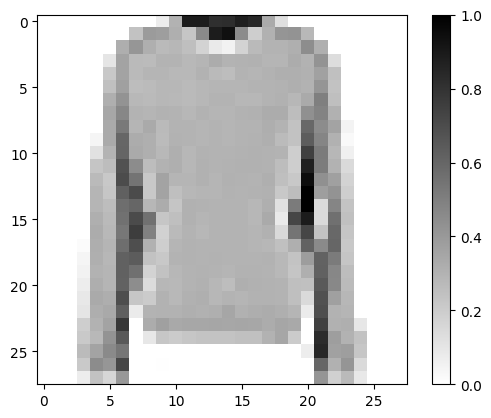

In [234]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28, 28))
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

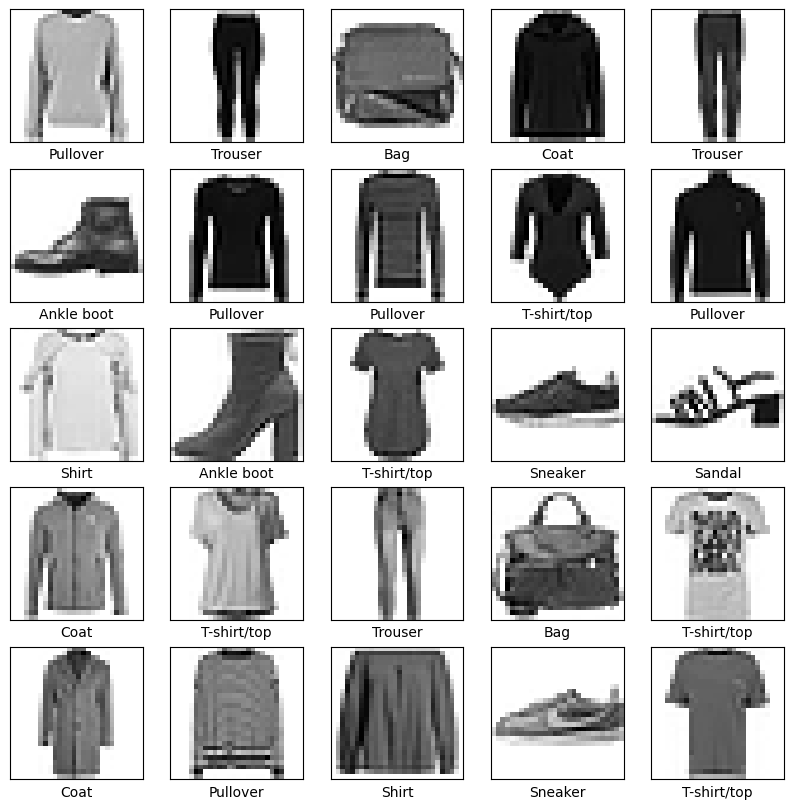

In [235]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28, 28))
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()

In [236]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

c:\Users\elyix\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [237]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [238]:
Tamano_lote = 32

In [239]:
num_ej_entrenamiento = metadatos.splits['train'].num_examples
num_ej_prueba = metadatos.splits['test'].num_examples
print(num_ej_entrenamiento)
print(num_ej_prueba)

60000
10000


In [240]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(Tamano_lote)
datos_prueba = datos_prueba.batch(Tamano_lote)

In [241]:
historial = modelo.fit(datos_entrenamiento, epochs=15, steps_per_epoch=math.ceil(num_ej_entrenamiento/Tamano_lote))

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7791 - loss: 0.6273
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8629 - loss: 0.3792
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8739 - loss: 0.3418
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8863 - loss: 0.3122
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8893 - loss: 0.2994
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8960 - loss: 0.2804
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9009 - loss: 0.2673
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9022 - loss: 0.2589
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9073 - loss: 0.2507
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9103 - loss: 0.2369
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9097 - loss: 0.2357
Epoch 12/15
1875/1875 ━━━━━━━━

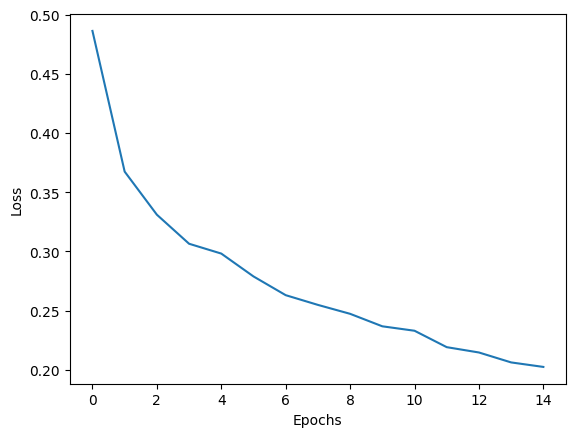

In [242]:
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(historial.history['loss'])

In [243]:
for imagenes_prueba, etiquetas_prueba in datos_prueba.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()
    
predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, predicciones_array, etiqueta_real, imagen):
    predicciones_array, etiqueta_real, imagen = predicciones_array, etiqueta_real[i], imagen[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(imagen[...,0], cmap=plt.cm.binary)

    prediccion_label = np.argmax(predicciones_array)
    if prediccion_label == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[prediccion_label],
                                100*np.max(predicciones_array),
                                nombres_clases[etiqueta_real]),
                                color=color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


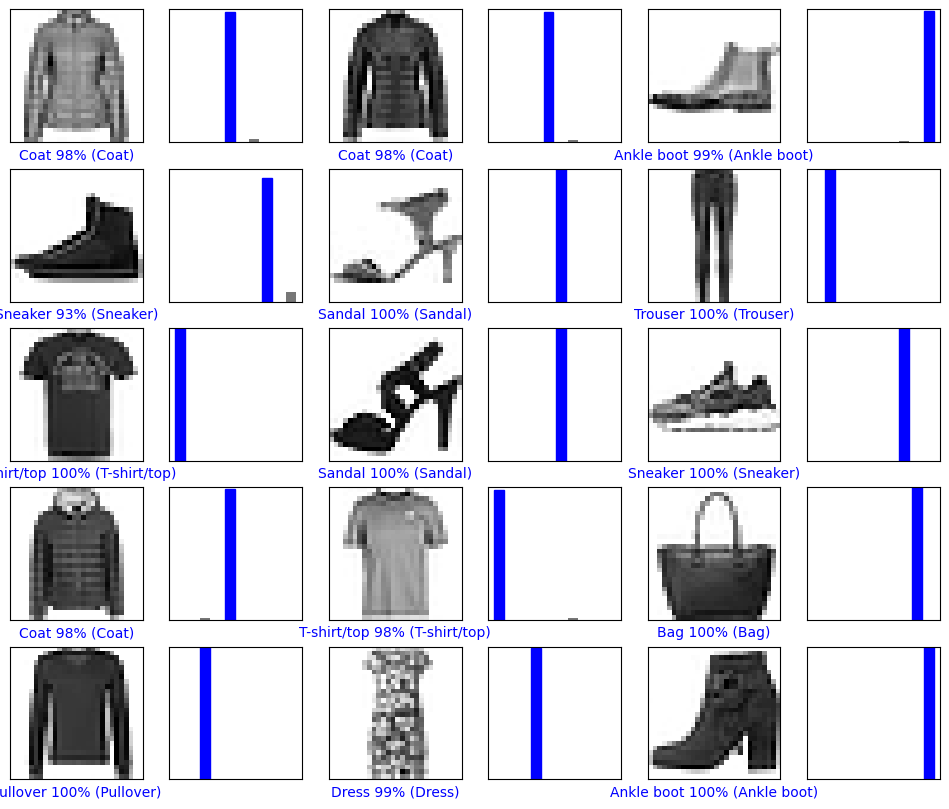

In [244]:
def grafica_valor_arreglo (i, predicciones_array, etiqueta_real):
    predicciones_array, etiqueta_real = predicciones_array, etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predicciones_array, color="#777777")
    plt.ylim([0, 1])
    prediccion_label = np.argmax(predicciones_array)

    thisplot[prediccion_label].set_color('red')
    thisplot[etiqueta_real].set_color('blue')

filas = 5
columnas = 3
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones[i], etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    grafica_valor_arreglo(i, predicciones[i], etiquetas_prueba)

In [245]:
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print("Prediccion:", nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediccion: T-shirt/top


## ¿Qué es el formato H5 y para qué sirve?

**HDF5 (Hierarchical Data Format version 5)** es un formato de archivo diseñado para almacenar y organizar grandes cantidades de datos de manera eficiente.

Características principales:
- **Jerárquico:** organiza los datos en grupos y datasets, similar a carpetas y archivos dentro de un sistema de archivos.
- **Eficiente:** permite lectura/escritura parcial sin cargar todo el archivo en memoria.
- **Multiplataforma:** funciona en Windows, Linux y macOS.
- **Compresión integrada:** puede comprimir datos para reducir el tamaño del archivo.

¿Para qué sirve en Machine Learning?
En el contexto de Keras y TensorFlow, el formato `.h5` se utiliza para **guardar modelos entrenados** de forma completa, incluyendo:

| Elemento guardado       | Descripción |
|------------------------|-------------|
| Arquitectura del modelo | Capas, neuronas, funciones de activación |
| Pesos entrenados        | Los valores aprendidos durante el entrenamiento |
| Configuración del optimizador | Estado del optimizador Adam |
| Métricas y pérdida      | Configuración de compilación del modelo |

### Ventajas:
- Permite **reutilizar el modelo** sin tener que entrenarlo de nuevo.
- Facilita el **despliegue** del modelo en aplicaciones reales.
- Compatible con múltiples lenguajes y frameworks (Python, R, MATLAB, Java).

In [246]:
modelo.save('modelo_fashion_mnist.h5')
print("Modelo guardado")    

Modelo guardado


In [248]:
url = input("URL: ")
respuesta = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
img = Image.open(io.BytesIO(respuesta.content)).convert('L')
img = ImageOps.autocontrast(img)
umbral = 127
img = img.point(lambda p: 255 if p > umbral else 0)
img = ImageOps.invert(img)
img = img.resize((28, 28), Image.LANCZOS)
img_array = np.array(img) / 255.0
img_array = img_array.reshape(1, 28, 28, 1)

pred = modelo.predict(img_array, verbose=0)
print("Predicción:", nombres_clases[np.argmax(pred)])

Predicción: Bag
